# Random Forest: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind random forests (bagging, bootstrap sampling, random feature subsets, voting)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

MODEL_NAME = "Random Forest"
MODEL_SLUG = "random_forest"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Random Forests

### 2.1 The Core Idea

A random forest is an **ensemble method** that reduces the high variance of a single decision tree by building many trees on random subsets of the training data and averaging their predictions. The key insight: **diversity is power**. If individual trees are trained on different data samples and make different mistakes, averaging them cancels out much of the noise while preserving the signal.

### 2.2 Bootstrap Aggregating (Bagging)

The core technique is **bootstrap aggregating** or **bagging**:

1. **For each tree** \(b = 1, 2, \ldots, B\):
   - Draw a random sample of \(n\) observations **with replacement** from the training set
   - Train a decision tree on this bootstrap sample
   - The tree grows to full depth (no pruning)

2. **For each new prediction**, aggregate the predictions:

$$\hat{y} = \text{majority vote}(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_B)$$

For probability predictions:

$$\hat{p} = \frac{1}{B} \sum_{b=1}^{B} \hat{p}_b(x)$$

### 2.3 Why Bootstrap Sampling?

By sampling with replacement, some observations appear multiple times in a bootstrap sample while others appear zero times. On average, each bootstrap sample contains roughly 63% of the original data:

$$P(\text{observation } i \text{ in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n \approx 1 - e^{-1} \approx 0.632$$

The remaining ~37% is called the **out-of-bag (OOB)** samples. These can be used for validation without requiring a separate test set.

### 2.4 Variance Reduction via Averaging

Suppose each tree has variance \(\sigma^2\) and the trees' predictions are **uncorrelated**. The variance of the average of \(B\) trees is:

$$\text{Var}(\hat{y}) = \frac{\sigma^2}{B}$$

This is the **key mathematical benefit**: variance drops as \(O(1/B)\). By training 100 uncorrelated trees instead of 1, we reduce variance by a factor of 100.

In practice, trees are not perfectly uncorrelated (they all see the same features and the same underlying patterns), so the reduction is smaller than this bound, but still substantial.

### 2.5 Random Feature Subsets (Random Forests)

Standard bagging trains each tree on a random sample of **observations**. Random forests add a second layer of randomness: at each split, only a random subset of \(m\) features are considered:

$$m = \sqrt{p} \quad \text{(default for classification)}$$

where \(p\) is the total number of features. For the HMEQ dataset with ~35 features, this means each split considers only \(\sqrt{35} \approx 6\) features.

**Why?** If one or two features are very strong predictors, every tree will split on them first, making the trees correlated. Random feature subsets force trees to find different patterns, decorrelating their predictions and improving the variance reduction.

### 2.6 Out-of-Bag (OOB) Error

Each tree \(b\) can be evaluated on its OOB samples (roughly 37% of the training data that were not in its bootstrap sample). This gives a free validation set:

$$\text{OOB error} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}[\hat{y}_{\text{OOB}}(x_i) \neq y_i]$$

where \(\hat{y}_{\text{OOB}}(x_i)\) is the prediction averaged only over trees for which observation \(i\) was OOB.

### 2.7 Feature Importance (Two Methods)

**Method 1: Mean Decrease in Impurity (MDI)**

Average the feature importance from each tree (the sum of impurity decreases across all nodes where the feature was split):

$$\text{Importance}_\text{MDI}(x_j) = \frac{1}{B} \sum_{b=1}^{B} \text{Importance}_b(x_j)$$

**Method 2: Permutation Importance**

Measure how much the OOB error increases when feature \(x_j\) is randomly shuffled (breaking the relationship between that feature and the target):

$$\text{Importance}_\text{perm}(x_j) = \text{OOB error}_{\text{shuffled } x_j} - \text{OOB error}_{\text{original}}$$

Permutation importance is more reliable than MDI because it measures the actual impact on the forest's predictions, not just the individual trees' internal Gini calculations.

---
## 3. Visualizing Variance Reduction Through Bagging

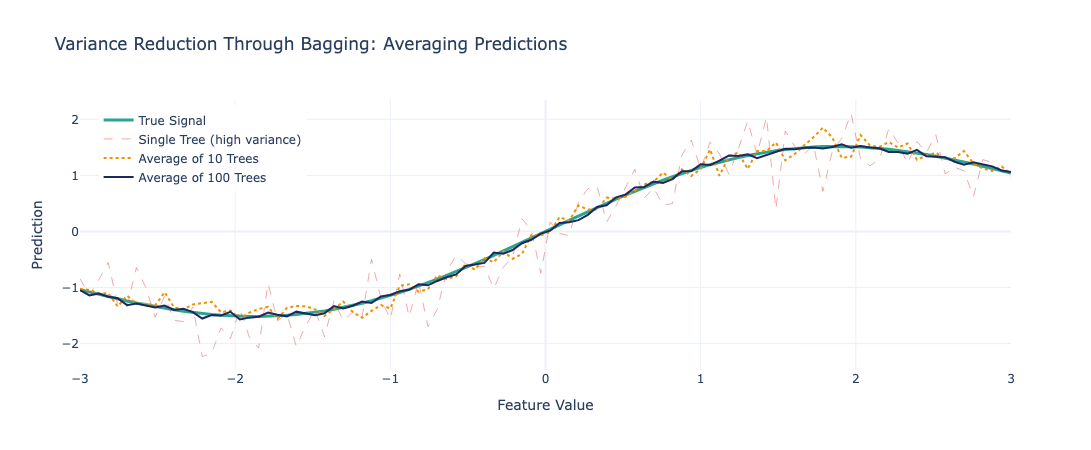

  Saved: outputs/random_forest/bagging_variance_reduction.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/random_forest/bagging_variance_reduction.html')

In [2]:
# Simulate variance reduction with averaging
# Each "tree" makes predictions with some noise; averaging reduces noise

np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y_true = np.sin(x) + x * 0.3

# Single noisy tree: high variance
y_single = y_true + np.random.normal(0, 0.4, len(x))

# 10 trees (ensemble average)
y_ensemble_10 = np.mean([y_true + np.random.normal(0, 0.4, len(x)) for _ in range(10)], axis=0)

# 100 trees (ensemble average)
y_ensemble_100 = np.mean([y_true + np.random.normal(0, 0.4, len(x)) for _ in range(100)], axis=0)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y_true, name="True Signal",
    line=dict(color=COLORS["green"], width=3)))
fig.add_trace(go.Scatter(x=x, y=y_single, name="Single Tree (high variance)",
    line=dict(color=COLORS["red"], width=1, dash="dash"), opacity=0.5))
fig.add_trace(go.Scatter(x=x, y=y_ensemble_10, name="Average of 10 Trees",
    line=dict(color=COLORS["orange"], width=2, dash="dot")))
fig.add_trace(go.Scatter(x=x, y=y_ensemble_100, name="Average of 100 Trees",
    line=dict(color=COLORS["navy"], width=2)))

fig.update_layout(
    title="Variance Reduction Through Bagging: Averaging Predictions",
    xaxis_title="Feature Value",
    yaxis_title="Prediction",
    height=450, width=700,
    legend=dict(x=0.02, y=0.98),
)
fig.show()
save_chart(fig, MODEL_SLUG, "bagging_variance_reduction")

---
## 4. Worked Example: Voting and Disagreement

In [3]:
print("="*70)
print("WORKED EXAMPLE: How Trees Vote in a Random Forest")
print("="*70)

# Get a few example borrowers
examples = get_example_rows(df, n=2)

for idx, row in examples.iterrows():
    print_example_row(row, idx)

print("\n" + "="*70)
print("Forest Voting Mechanism")
print("="*70)

print(f"""
Suppose we train a Random Forest with 100 trees on the HMEQ data.
Each tree is trained on a different bootstrap sample and considers
a random subset of features at each split.

Example: For one borrower, here's how the forest votes:

  Tree 1: Predict GOOD  (prob = 0.8)
  Tree 2: Predict DEFAULT (prob = 0.6)
  Tree 3: Predict GOOD (prob = 0.9)
  Tree 4: Predict GOOD (prob = 0.75)
  Tree 5: Predict DEFAULT (prob = 0.55)
  ...
  Tree 100: Predict GOOD (prob = 0.85)

Votes:
  GOOD:    78 votes (78%)
  DEFAULT: 22 votes (22%)

Forest Decision:
  Majority vote: GOOD (78 > 22)
  Probability: P(Default) = 22/100 = 0.22

Why this matters:
  - Tree 2 and 5 said DEFAULT, but they were outvoted
  - Individual trees can be noisy (high variance)
  - Voting averages out the noise
  - The consensus is more stable than any single tree

Bias-Variance Tradeoff:
  - Trees are trained to full depth (low bias, high variance)
  - Bagging increases bias slightly but reduces variance dramatically
  - Net result: lower test error than a single tree
""")

WORKED EXAMPLE: How Trees Vote in a Random Forest

--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

--- Example Borrower 2 (Actual: DEFAULT) ---
  LOAN           : 9900
  MORTDUE        : 71371.0
  VALUE          : 84865.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 0.0
  DEROG          : 2.0
  DELINQ         : 0.0
  CLAGE          : 94.805235749
  NINQ           : 0.0
  CLNO           : 12.0
  DEBTINC        : 38.211305102

Forest Voting Mechanism

Suppose we train a Random Forest with 100 trees on the HMEQ data.
Each tree is trained on a different bootstrap sample and considers
a random subset of features at each split.

Example: For one borrower, here's ho

---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# Hyperparameter grid
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [5, 10, 15, 20, None],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        oob_score=True,
        n_jobs=-1,
    )),
])

grid = GridSearchCV(
    rf_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True, verbose=1,
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV recall: {grid.best_score_:.4f}")

# Get the underlying forest
forest_model = best_rf.named_steps["clf"]
print(f"\nForest structure:")
print(f"  Number of trees: {forest_model.n_estimators}")
print(f"  Max features per split: {forest_model.max_features}")
print(f"  OOB score: {forest_model.oob_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters: {'clf__max_depth': 20, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Best CV recall: 0.7836

Forest structure:
  Number of trees: 200
  Max features per split: log2
  OOB score: 0.8747


---
## 6. Model Evaluation

In [5]:
# Cross-validation score
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_rf, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.7752809  0.78651685 0.7752809  0.75418994 0.82681564]
CV Recall mean: 0.7836 (+/- 0.0240)

  Random Forest
  Recall: 0.7710  |  Precision: 0.6543  |  F1: 0.7079
  AUC: 0.9252  |  PR-AUC: 0.7840
  Confusion: TP=229 FP=121 FN=68 TN=1072

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.94      0.90      0.92      1193
     Default       0.65      0.77      0.71       297

    accuracy                           0.87      1490
   macro avg       0.80      0.83      0.81      1490
weighted avg       0.88      0.87      0.88      1490



---
## 7. Out-of-Bag Error Curve

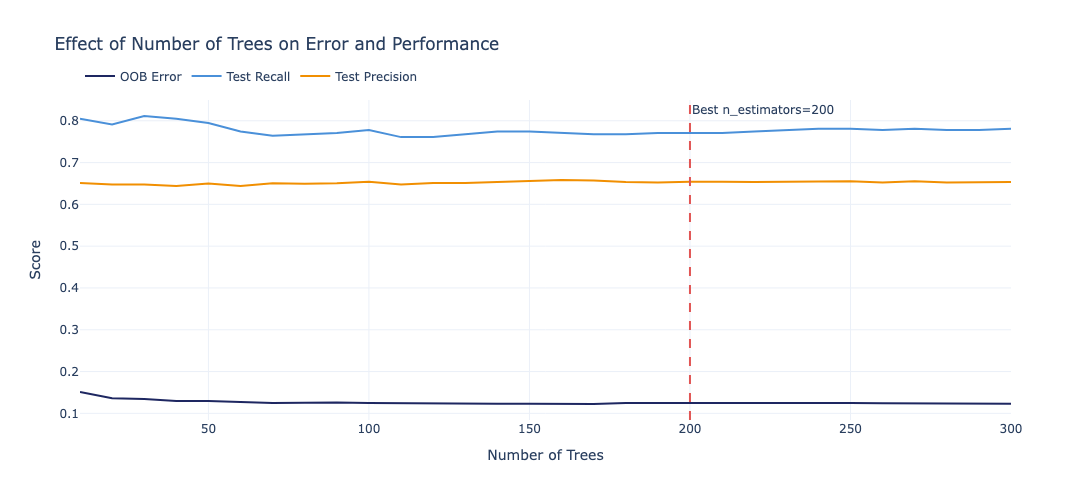

  Saved: outputs/random_forest/oob_error_curve.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/random_forest/oob_error_curve.html')

In [6]:
# Train forests with increasing numbers of trees
# to see how OOB error decreases

n_trees_range = list(range(10, 310, 10))
oob_scores = []
test_recalls = []
test_precisions = []

for n_trees in n_trees_range:
    rf_temp = Pipeline([
        ("prep", prep_tree),
        ("clf", RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=forest_model.max_depth,
            min_samples_leaf=forest_model.min_samples_leaf,
            max_features=forest_model.max_features,
            class_weight="balanced",
            oob_score=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    rf_temp.fit(X_train, y_train)
    
    # OOB score (higher is better; sklearn converts from error)
    oob_acc = rf_temp.named_steps["clf"].oob_score_
    oob_scores.append(1 - oob_acc)  # Convert to error
    
    # Test set
    y_pred_t = rf_temp.predict(X_test)
    test_recalls.append(recall_score(y_test, y_pred_t))
    test_precisions.append(precision_score(y_test, y_pred_t, zero_division=0))

fig_oob = go.Figure()
fig_oob.add_trace(go.Scatter(
    x=n_trees_range, y=oob_scores,
    name="OOB Error", mode="lines",
    line=dict(color=COLORS["navy"], width=2),
))
fig_oob.add_trace(go.Scatter(
    x=n_trees_range, y=test_recalls,
    name="Test Recall", mode="lines",
    line=dict(color=COLORS["accent"], width=2),
))
fig_oob.add_trace(go.Scatter(
    x=n_trees_range, y=test_precisions,
    name="Test Precision", mode="lines",
    line=dict(color=COLORS["orange"], width=2),
))

# Mark best n_estimators
best_n = forest_model.n_estimators
fig_oob.add_vline(x=best_n, line_dash="dash", line_color=COLORS["red"],
                  annotation_text=f"Best n_estimators={best_n}")

fig_oob.update_layout(
    title="Effect of Number of Trees on Error and Performance",
    xaxis_title="Number of Trees",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_oob.show()
save_chart(fig_oob, MODEL_SLUG, "oob_error_curve")

---
## 8. Feature Importance: Mean Decrease in Impurity (MDI)

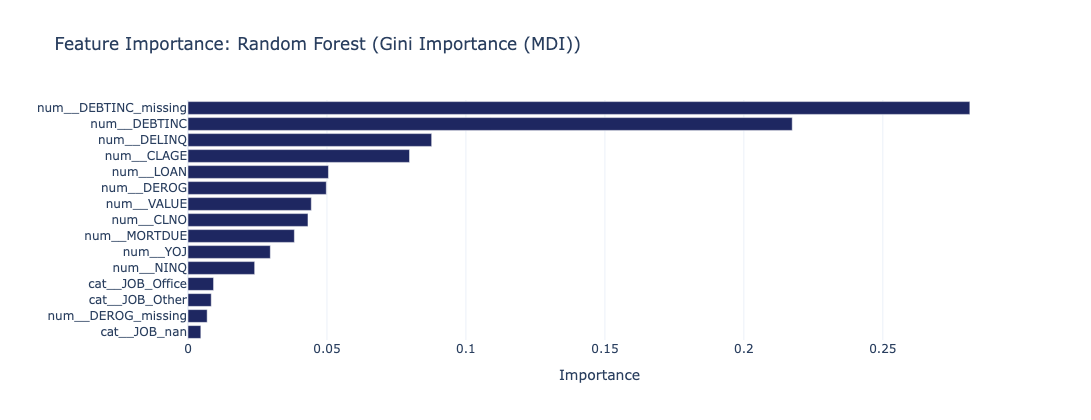

  Saved: outputs/random_forest/feature_importance_mdi.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/random_forest/feature_importance_mdi.html')

In [7]:
# Feature names after preprocessing
preprocessor = best_rf.named_steps["prep"]
all_feature_names = list(preprocessor.get_feature_names_out())

# MDI from the forest
importances_mdi = forest_model.feature_importances_

fig_mdi = plot_feature_importance(importances_mdi, all_feature_names, MODEL_NAME, "Gini Importance (MDI)")
fig_mdi.show()
save_chart(fig_mdi, MODEL_SLUG, "feature_importance_mdi")

---
## 9. Feature Importance: Permutation Importance

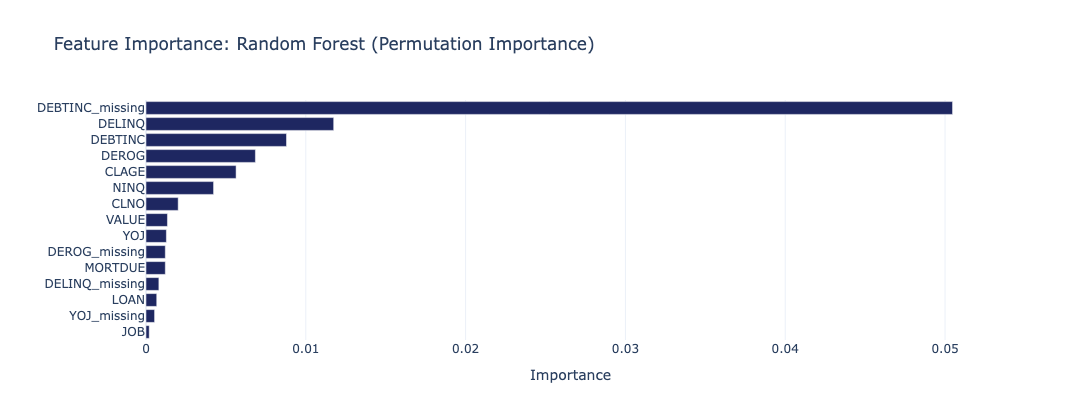

  Saved: outputs/random_forest/feature_importance_permutation.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/random_forest/feature_importance_permutation.html')

In [9]:
# Permutation importance on test set
perm_importance = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
importances_perm = perm_importance.importances_mean

# Use transformed feature names that match the array length
if hasattr(X_test, "columns"):
    perm_names = list(X_test.columns)
else:
    perm_names = [f"Feature {i}" for i in range(len(importances_perm))]

fig_perm = plot_feature_importance(importances_perm, perm_names, MODEL_NAME, "Permutation Importance")
fig_perm.show()
save_chart(fig_perm, MODEL_SLUG, "feature_importance_permutation")

---
## 10. Individual Tree Variance

In [10]:
# Transform test set for individual tree predictions
X_test_transformed = best_rf.named_steps["prep"].transform(X_test)

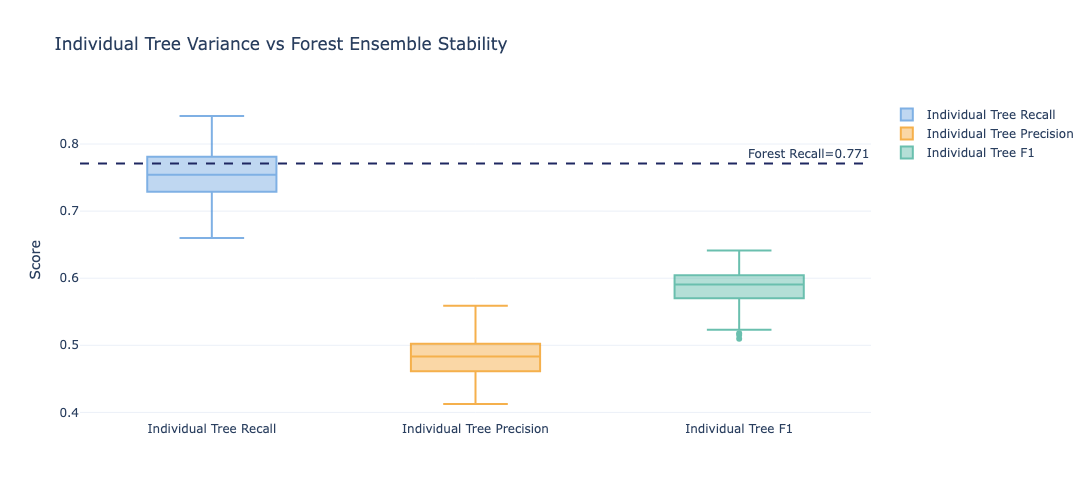

  Saved: outputs/random_forest/individual_tree_variance.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/random_forest/individual_tree_variance.html')

In [11]:
# Train individual trees from the forest on test set
# to show variance in single tree predictions

individual_recalls = []
individual_precisions = []
individual_f1s = []

for tree_estimator in forest_model.estimators_:
    y_pred_tree = tree_estimator.predict(X_test_transformed)
    individual_recalls.append(recall_score(y_test, y_pred_tree))
    individual_precisions.append(precision_score(y_test, y_pred_tree, zero_division=0))
    individual_f1s.append(f1_score(y_test, y_pred_tree))

# Get forest performance
forest_recall = recall_score(y_test, y_pred)
forest_precision = precision_score(y_test, y_pred, zero_division=0)
forest_f1 = f1_score(y_test, y_pred)

# Visualization
fig_var = go.Figure()

# Individual trees
fig_var.add_trace(go.Box(
    y=individual_recalls, name="Individual Tree Recall",
    marker_color=COLORS["accent"], opacity=0.7,
))
fig_var.add_trace(go.Box(
    y=individual_precisions, name="Individual Tree Precision",
    marker_color=COLORS["orange"], opacity=0.7,
))
fig_var.add_trace(go.Box(
    y=individual_f1s, name="Individual Tree F1",
    marker_color=COLORS["green"], opacity=0.7,
))

# Forest ensemble (horizontal line)
fig_var.add_hline(y=forest_recall, line_dash="dash", line_color=COLORS["navy"],
                  annotation_text=f"Forest Recall={forest_recall:.3f}")

fig_var.update_layout(
    title="Individual Tree Variance vs Forest Ensemble Stability",
    yaxis_title="Score",
    height=500, width=700,
)
fig_var.show()
save_chart(fig_var, MODEL_SLUG, "individual_tree_variance")

---
## 11. Diagnostic Charts


Saving universal charts for Random Forest:
  Saved: outputs/random_forest/roc_curve.html
  Saved: outputs/random_forest/precision_recall_curve.html
  Saved: outputs/random_forest/confusion_matrix.html
  Saved: outputs/random_forest/threshold_sweep.html


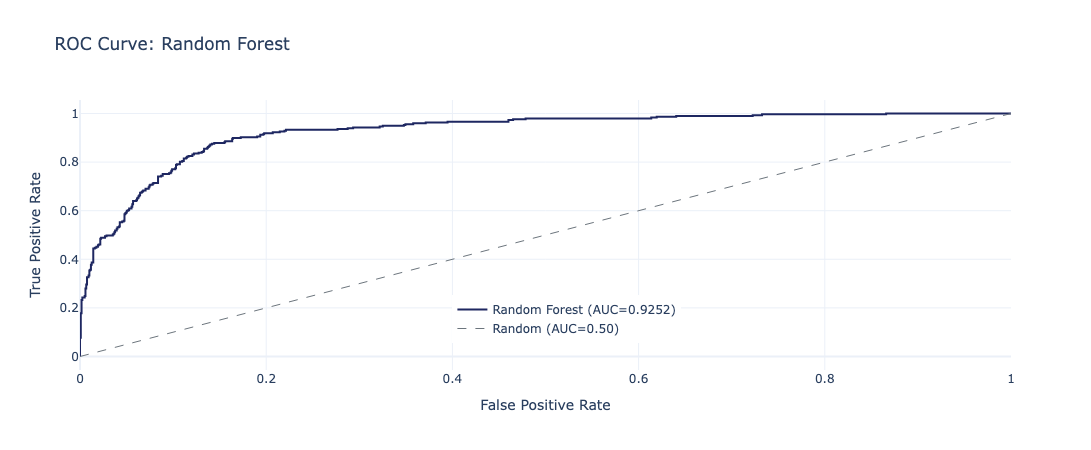

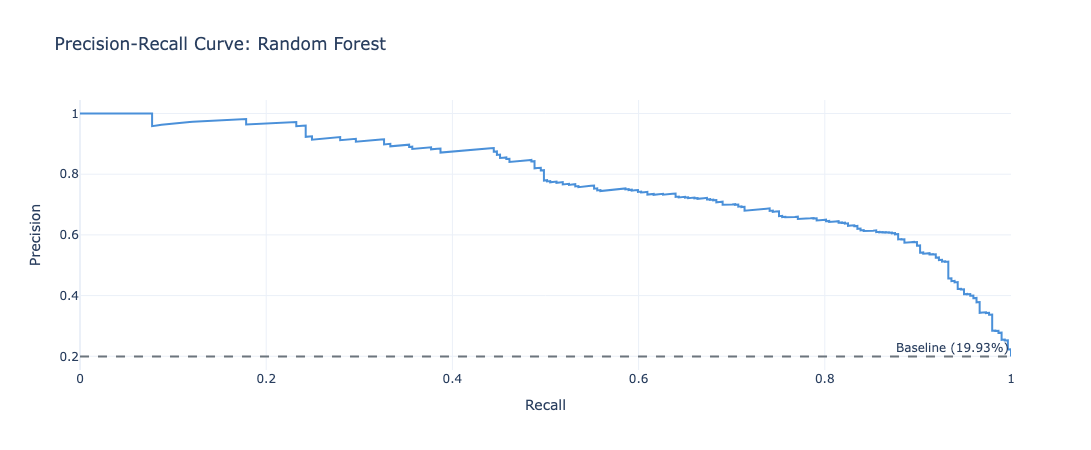

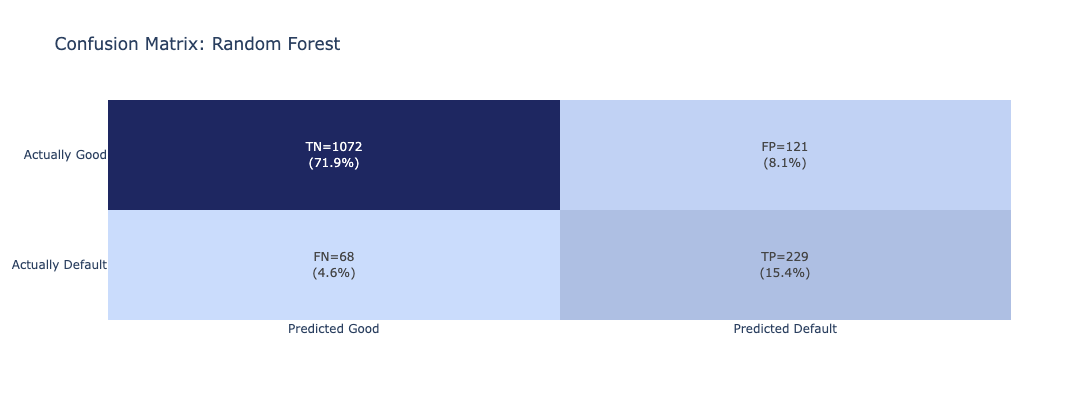

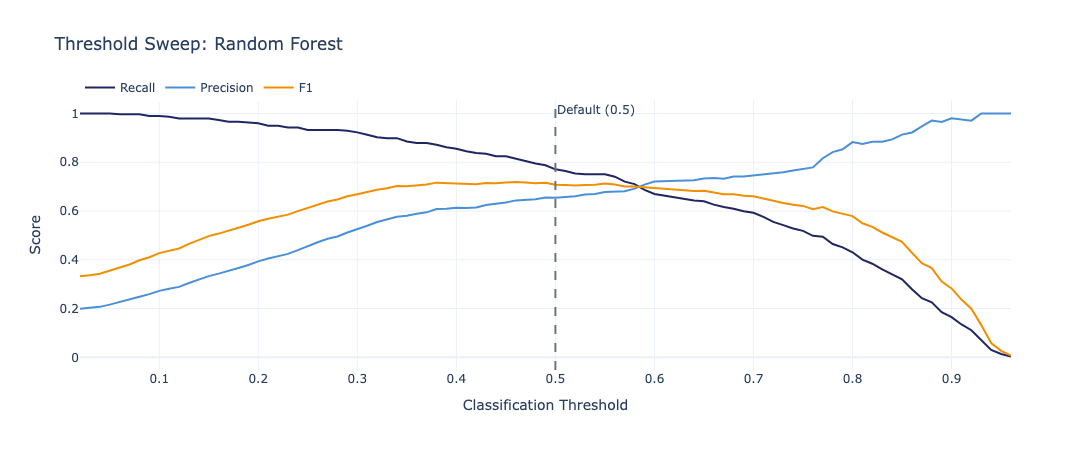

In [12]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

for name, fig in charts.items():
    fig.show()

---
## 12. Summary

### Where the Random Forest Sits on the Tradeoff Spectrum

Random forests with `class_weight="balanced"` land in the **moderate to aggressive** zone. By using many decorrelated trees with balanced class weights, the forest captures nonlinear patterns while maintaining reasonable recall. Compared to a single decision tree, the forest is more stable (lower variance) and typically achieves better generalization.

### Strengths for This Problem
- **Dramatic variance reduction**: bagging reduces the high variance of single trees
- **Captures nonlinear patterns**: unlike linear models, can model complex feature interactions
- **Handles mixed feature types**: works with numeric and categorical features natively
- **Feature importance**: both MDI and permutation importance provide interpretability
- **Out-of-bag validation**: free estimate of generalization error without a separate test set
- **Parallel training**: trees are independent and can be trained in parallel
- **Robust to outliers**: individual trees are robust, and outliers' impact is reduced by averaging

### Limitations for This Problem
- **Less interpretable than single trees**: the ensemble decision is a vote across 100+ trees
- **More computationally expensive**: training and prediction are slower than single trees
- **Still biased toward strong features**: if one feature is dominant, all trees may use it
- **Modest further improvements**: boosting methods (XGBoost, LightGBM) often outperform bagging

### Key Takeaway
Random forests are the **practical nonlinear classifier**. They dramatically improve over single trees while remaining reasonably interpretable. They serve as the go-to baseline for structured data classification before trying more sophisticated methods.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*